In [1]:
!pip install -q scikeras

In [2]:
# Settings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, models, optimizers
from keras.applications import VGG16
from keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

np.random.seed(42)
tf.random.set_seed(42)
keras.utils.set_random_seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Set all text weights and sizes to 14 Bold globally
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Ensure individual components inherit the bold styling and size
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Apply bold to axis tick numbers
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Task-1: Dataset Preparation

In [3]:
# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 class labels
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# 2. Normalize pixel values to range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode targets for categorical crossentropy
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 4. Print dataset dimensions
print(f"Training Data Shape: {x_train.shape}, Labels Shape: {y_train_cat.shape}")
print(f"Testing Data Shape:  {x_test.shape}, Labels Shape:  {y_test_cat.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2754s 16us/step
Training Data Shape: (50000, 32, 32, 3), Labels Shape: (50000, 10)
Testing Data Shape:  (10000, 32, 32, 3), Labels Shape:  (10000, 10)


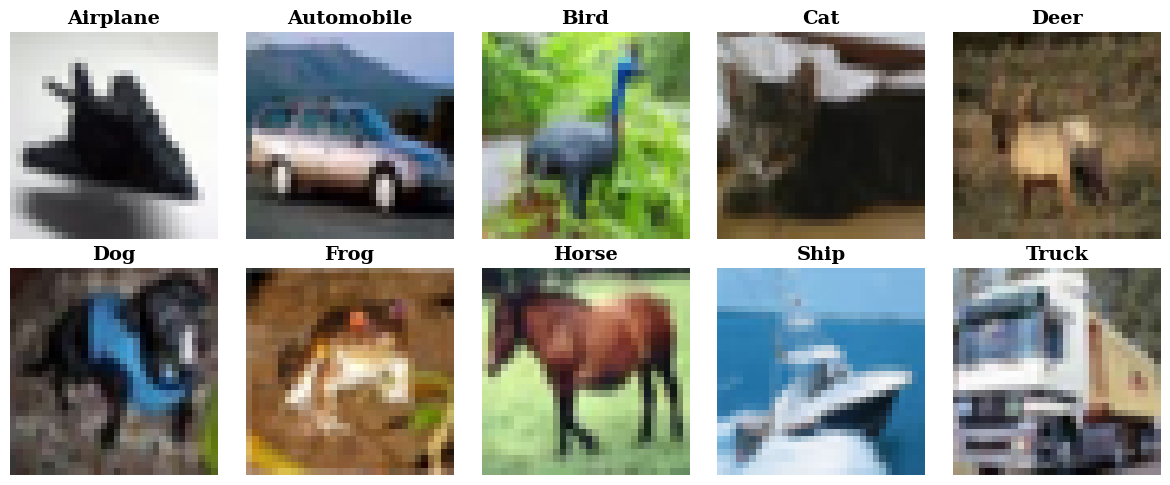

In [4]:
# Display 10 sample images (one from each class)
plt.figure(figsize=(12, 5))
unique_indices = [np.where(y_train == i)[0][0] for i in range(10)]

for idx, img_idx in enumerate(unique_indices):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_train[img_idx])
    plt.title(f"{class_names[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('cifar10_samples.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Task-2: Transfer Learning

In [5]:
# 1-3. Load pretrained VGG16 base and freeze weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 4-6. Build custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

I0000 00:00:1787780314.863355      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787780314.866780      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Task-3: Model Training

In [6]:
# Compile the model
optimizer = optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the top classifier layers
EPOCHS_PHASE_1 = 10
BATCH_SIZE = 32

history_phase1 = model.fit(
    x_train, y_train_cat,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_PHASE_1,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
  24/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1290 - loss: 2.3742

I0000 00:00:1787780326.688122      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4904 - loss: 1.4501 - val_accuracy: 0.5580 - val_loss: 1.2500
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5637 - loss: 1.2451 - val_accuracy: 0.5806 - val_loss: 1.1957
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5858 - loss: 1.1810 - val_accuracy: 0.5853 - val_loss: 1.1775
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5975 - loss: 1.1414 - val_accuracy: 0.5937 - val_loss: 1.1517
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6097 - loss: 1.1076 - val_accuracy: 0.6002 - val_loss: 1.1445
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6198 - loss: 1.0819 - val_accuracy: 0.6046 - val_loss: 1.1329
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6295 - loss: 1.0579 - val_accuracy: 0.6100 - val_loss: 1.1293
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6361 - loss: 1.0334 - 

# Task-4: Fine Tuning

In [7]:
# 1. Unfreeze the base model and freeze all except the last convolutional block
base_model.trainable = True

# VGG16 block 5 layers: block5_conv1, block5_conv2, block5_conv3, block5_pool
for layer in base_model.layers:
    if "block5" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# 2. Recompile with a lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train for additional epochs
EPOCHS_PHASE_2 = 10
total_epochs = EPOCHS_PHASE_1 + EPOCHS_PHASE_2

history_phase2 = model.fit(
    x_train, y_train_cat,
    batch_size=BATCH_SIZE,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1] + 1,
    validation_split=0.2,
    verbose=1
)

# Combine training histories for plotting
combined_acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
combined_val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
combined_loss = history_phase1.history['loss'] + history_phase2.history['loss']
combined_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.6260 - loss: 1.0828 - val_accuracy: 0.6896 - val_loss: 0.9027
Epoch 12/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7167 - loss: 0.8056 - val_accuracy: 0.7117 - val_loss: 0.8475
Epoch 13/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7693 - loss: 0.6425 - val_accuracy: 0.7162 - val_loss: 0.8523
Epoch 14/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8140 - loss: 0.5134 - val_accuracy: 0.7140 - val_loss: 0.9705
Epoch 15/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8508 - loss: 0.4112 - val_accuracy: 0.7125 - val_loss: 1.0780
Epoch 16/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8763 - loss: 0.3387 - val_accuracy: 0.7099 - val_loss: 1.1546
Epoch 17/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9041 - loss: 0.2657 - val_accuracy: 0.7163 - val_loss: 1.1887
Epoch 18/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


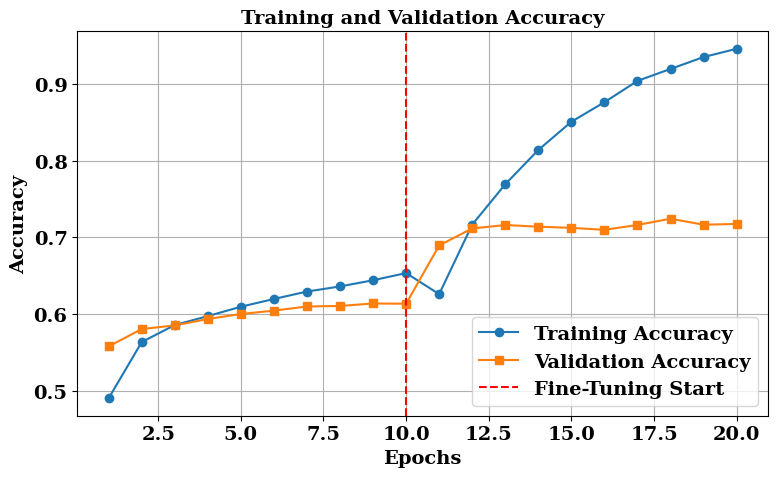

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, total_epochs + 1), combined_acc, marker='o', label='Training Accuracy')
plt.plot(range(1, total_epochs + 1), combined_val_acc, marker='s', label='Validation Accuracy')
plt.axvline(x=EPOCHS_PHASE_1, color='r', linestyle='--', label='Fine-Tuning Start')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('accuracy_curves.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


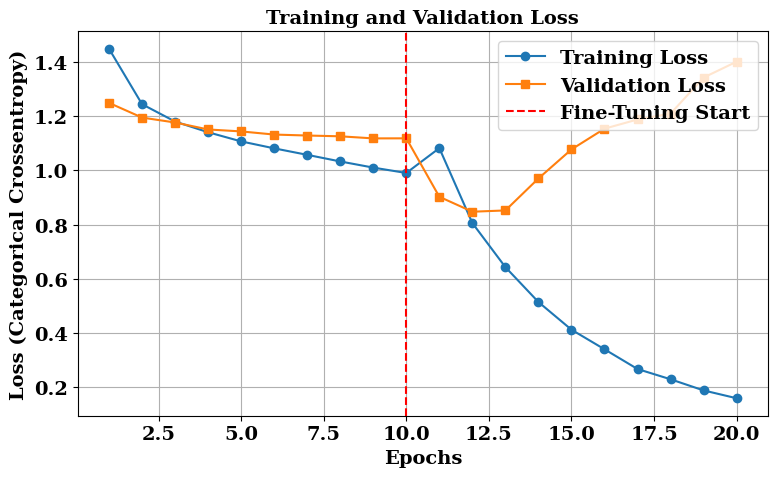

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, total_epochs + 1), combined_loss, marker='o', label='Training Loss')
plt.plot(range(1, total_epochs + 1), combined_val_loss, marker='s', label='Validation Loss')
plt.axvline(x=EPOCHS_PHASE_1, color='r', linestyle='--', label='Fine-Tuning Start')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curves.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Task-5: Model Evaluation

In [10]:
# Predict probabilities and assign classes
y_pred_probs = model.predict(x_test, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Calculate performance metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print("=" * 50)
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Weighted F1    : {f1:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted Prec. : {precision:.4f}")
print("=" * 50)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Test Accuracy  : 0.7119
Weighted F1    : 0.7064
Weighted Recall: 0.7119
Weighted Prec. : 0.7105

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.74      0.83      0.78      1000
  Automobile       0.83      0.82      0.82      1000
        Bird       0.64      0.69      0.66      1000
         Cat       0.60      0.39      0.47      1000
        Deer       0.70      0.58      0.64      1000
         Dog       0.62      0.60      0.61      1000
        Frog       0.72      0.77      0.74      1000
       Horse       0.66      0.87      0.75      1000
        Ship       0.85      0.77      0.81      1000
       Truck       0.75      0.81      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



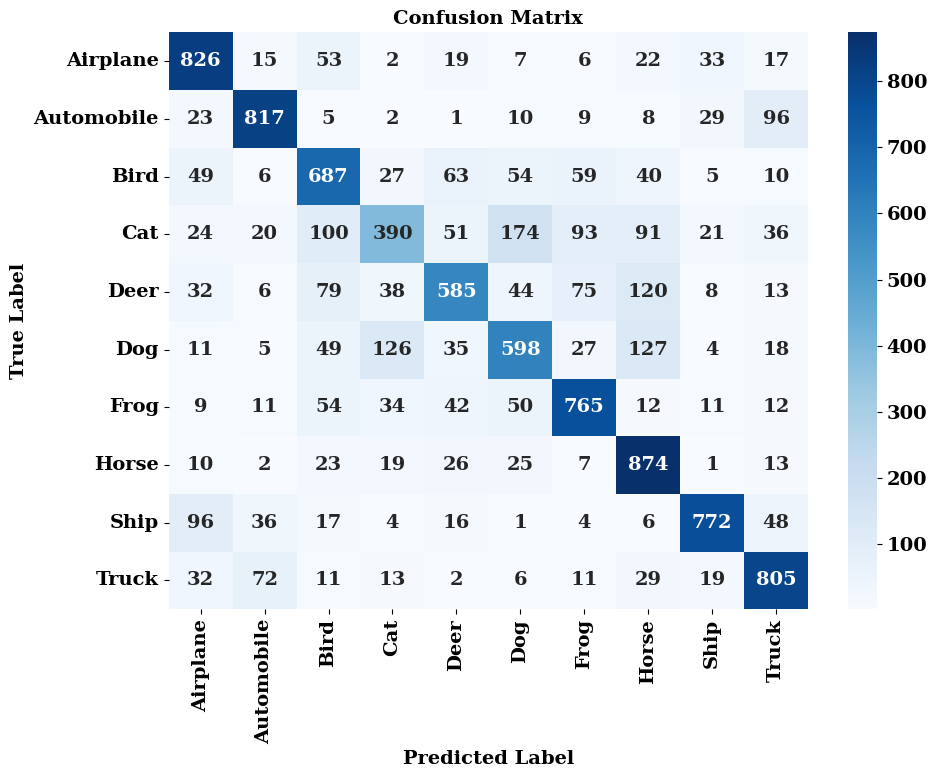

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

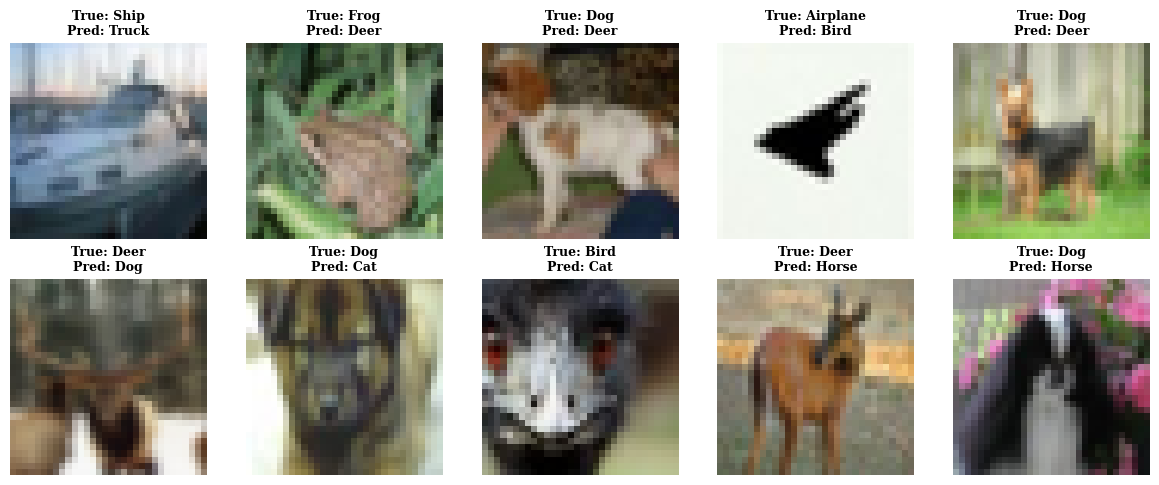

In [12]:
# Identify misclassified index locations
misclassified_indices = np.where(y_pred != y_true)[0]

plt.figure(figsize=(12, 5))
for idx in range(min(10, len(misclassified_indices))):
    mis_idx = misclassified_indices[idx]
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_test[mis_idx])
    plt.title(f"True: {class_names[y_true[mis_idx]]}\nPred: {class_names[y_pred[mis_idx]]}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.savefig('misclassified_images.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Hyperparameter Study

In [13]:
from sklearn.model_selection import RandomizedSearchCV
import scikeras.wrappers
from scikeras.wrappers import KerasClassifier

# Universal patch for scikit-learn 1.6+ and SciKeras MRO tag lookup
try:
    from sklearn.base import BaseEstimator
    scikeras.wrappers.BaseWrapper.__sklearn_tags__ = lambda self: BaseEstimator.__sklearn_tags__(self)
except Exception:
    try:
        from sklearn.utils._tags import Tags, TargetTags, ClassifierTags
        scikeras.wrappers.BaseWrapper.__sklearn_tags__ = lambda self: Tags(
            estimator_type="classifier",
            target_tags=TargetTags(),
            classifier_tags=ClassifierTags()
        )
    except Exception:
        pass


def create_transfer_model(learning_rate=0.001, optimizer='adam', dense_units=128, frozen_layers='all'):
    """Factory function for SciKeras KerasClassifier."""
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

    if frozen_layers == 'all':
        base.trainable = False
    elif frozen_layers == 'partial':
        base.trainable = True
        for layer in base.layers:
            layer.trainable = True if "block5" in layer.name else False

    net = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    if optimizer == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    net.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return net


# Initialize SciKeras KerasClassifier
scikeras_model = KerasClassifier(
    model=create_transfer_model,
    learning_rate=0.001,
    optimizer='adam',
    dense_units=128,
    frozen_layers='all',
    verbose=0
)

# Hyperparameter distributions matching the lab manual table
param_distributions = {
    'model__learning_rate': [0.001, 0.0001],
    'model__optimizer': ['adam', 'sgd'],
    'model__dense_units': [128, 256],
    'model__frozen_layers': ['all', 'partial'],
    'batch_size': [16, 32, 64],
    'epochs': [10, 20]
}

# Fast search evaluating 4 randomly sampled parameter combinations
random_search = RandomizedSearchCV(
    estimator=scikeras_model,
    param_distributions=param_distributions,
    n_iter=45,
    scoring='accuracy',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=1
)

search_result = random_search.fit(x_train[:2000], y_train[:2000].flatten())

print("=" * 60)
print(f"Best Hyperparameter Configuration: {search_result.best_params_}")
print(f"Best Cross-Validation Score:       {search_result.best_score_:.4f}")
print("=" * 60)

Fitting 2 folds for each of 45 candidates, totalling 90 fits
[CV] END batch_size=64, epochs=20, model__dense_units=128, model__frozen_layers=all, model__learning_rate=0.001, model__optimizer=adam; total time=  12.3s
[CV] END batch_size=64, epochs=20, model__dense_units=128, model__frozen_layers=all, model__learning_rate=0.001, model__optimizer=adam; total time=  10.3s
[CV] END batch_size=64, epochs=10, model__dense_units=256, model__frozen_layers=partial, model__learning_rate=0.001, model__optimizer=sgd; total time=  11.9s
[CV] END batch_size=64, epochs=10, model__dense_units=256, model__frozen_layers=partial, model__learning_rate=0.001, model__optimizer=sgd; total time=   9.6s
[CV] END batch_size=64, epochs=10, model__dense_units=256, model__frozen_layers=all, model__learning_rate=0.001, model__optimizer=sgd; total time=   7.6s
[CV] END batch_size=64, epochs=10, model__dense_units=256, model__frozen_layers=all, model__learning_rate=0.001, model__optimizer=sgd; total time=   7.5s
[CV] 

In [14]:
import time
import numpy as np
import tensorflow as tf
from keras import layers, models, optimizers
from keras.applications import ResNet50
from sklearn.metrics import classification_report, precision_recall_fscore_support

# 1. Load pretrained ResNet50 base and freeze weights
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
resnet_base.trainable = False

# 2. Build custom classification head
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train ResNet50 model
start_time = time.time()
resnet_history = resnet_model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)
resnet_train_time = time.time() - start_time

# 4. Evaluate ResNet50
resnet_preds = np.argmax(resnet_model.predict(x_test), axis=1)
p, r, f1, _ = precision_recall_fscore_support(y_test.flatten(), resnet_preds, average='weighted')
_, resnet_acc = resnet_model.evaluate(x_test, y_test_cat, verbose=0)

print(f"ResNet50 Test Accuracy : {resnet_acc * 100:.2f}%")
print(f"ResNet50 F1-Score      : {f1:.4f}")
print(f"ResNet50 Training Time : {resnet_train_time:.2f}s")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.1779 - loss: 2.1972 - val_accuracy: 0.2447 - val_loss: 2.0327
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2184 - loss: 2.0766 - val_accuracy: 0.2639 - val_loss: 1.9739
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2310 - loss: 2.0433 - val_accuracy: 0.2706 - val_loss: 1.9362
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2420 - loss: 2.0208 - val_accuracy: 0.2802 - val_loss: 1.9223
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2477 - loss: 2.0097 - val_accuracy: 0.2998 - val_loss: 1.8892
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2503 - loss: 1.9987 - val_accuracy: 0.2888 - val_loss: 1.8859
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2537 - loss: 1.9846 - val_accuracy: 0.2980 - val_loss: 1.8846
Epoch 8/10
1250/1250 ━━━━━━━━━━

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


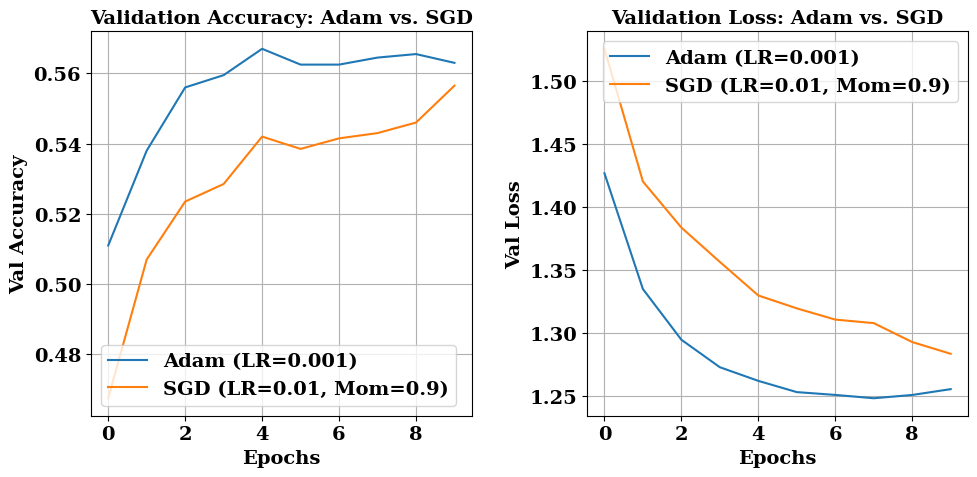

In [15]:
import matplotlib.pyplot as plt

def build_transfer_base():
    """Helper function to return identical frozen VGG16 model architectures."""
    base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    return models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

# 1. Train model with Adam Optimizer
model_adam = build_transfer_base()
model_adam.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_adam = model_adam.fit(
    x_train[:10000], y_train_cat[:10000],
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=0
)

# 2. Train model with SGD Optimizer (Momentum = 0.9)
model_sgd = build_transfer_base()
model_sgd.compile(
    optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_sgd = model_sgd.fit(
    x_train[:10000], y_train_cat[:10000],
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=0
)

# 3. Plot optimizer comparison curve
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['val_accuracy'], label='Adam (LR=0.001)')
plt.plot(history_sgd.history['val_accuracy'], label='SGD (LR=0.01, Mom=0.9)')
plt.title('Validation Accuracy: Adam vs. SGD')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_adam.history['val_loss'], label='Adam (LR=0.001)')
plt.plot(history_sgd.history['val_loss'], label='SGD (LR=0.01, Mom=0.9)')
plt.title('Validation Loss: Adam vs. SGD')
plt.xlabel('Epochs')
plt.ylabel('Val Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('optimizer_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

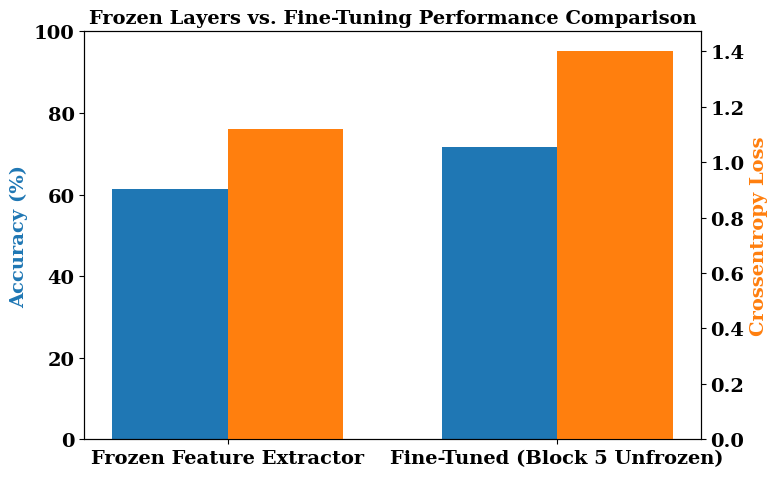

In [16]:
# Extract metrics before and after fine-tuning from Task 3 & Task 4 histories
acc_frozen = history_phase1.history['val_accuracy'][-1]
loss_frozen = history_phase1.history['val_loss'][-1]
acc_finetuned = history_phase2.history['val_accuracy'][-1]
loss_finetuned = history_phase2.history['val_loss'][-1]

strategies = ['Frozen Feature Extractor', 'Fine-Tuned (Block 5 Unfrozen)']
val_accuracies = [acc_frozen * 100, acc_finetuned * 100]
val_losses = [loss_frozen, loss_finetuned]

fig, ax1 = plt.subplots(figsize=(8, 5))
x = np.arange(len(strategies))
width = 0.35

rects1 = ax1.bar(x - width/2, val_accuracies, width, label='Validation Accuracy (%)', color='#1f77b4')
ax1.set_ylabel('Accuracy (%)', color='#1f77b4')
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, val_losses, width, label='Validation Loss', color='#ff7f0e')
ax2.set_ylabel('Crossentropy Loss', color='#ff7f0e')

ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.set_title('Frozen Layers vs. Fine-Tuning Performance Comparison')

plt.tight_layout()
plt.savefig('frozen_vs_finetuned.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [17]:
import time
import pandas as pd
from keras import layers, models, optimizers
from sklearn.metrics import precision_recall_fscore_support

# 1. Define LeNet-5 for CIFAR-10 (32x32x3)
def build_lenet5():
    return models.Sequential([
        layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 3), padding='same'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ], name="LeNet-5")

# 2. Define AlexNet adapted for 32x32 CIFAR-10 images
def build_alexnet():
    return models.Sequential([
        layers.Conv2D(96, kernel_size=(3, 3), strides=1, activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name="AlexNet")

# 3. Define GoogleNet (Inception Network) for CIFAR-10
def inception_module(x, f_1x1, f_3x3_r, f_3x3, f_5x5_r, f_5x5, f_pool):
    # 1x1 conv branch
    b1 = layers.Conv2D(f_1x1, (1, 1), padding='same', activation='relu')(x)
    
    # 1x1 conv -> 3x3 conv branch
    b2 = layers.Conv2D(f_3x3_r, (1, 1), padding='same', activation='relu')(x)
    b2 = layers.Conv2D(f_3x3, (3, 3), padding='same', activation='relu')(b2)
    
    # 1x1 conv -> 5x5 conv branch
    b3 = layers.Conv2D(f_5x5_r, (1, 1), padding='same', activation='relu')(x)
    b3 = layers.Conv2D(f_5x5, (5, 5), padding='same', activation='relu')(b3)
    
    # 3x3 max pooling -> 1x1 conv branch
    b4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    b4 = layers.Conv2D(f_pool, (1, 1), padding='same', activation='relu')(b4)
    
    return layers.concatenate([b1, b2, b3, b4], axis=-1)

def build_googlenet():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2), strides=2, padding='same')(x)
    
    # Inception Blocks (3a, 3b)
    x = inception_module(x, 32, 48, 64, 8, 16, 16)
    x = inception_module(x, 64, 64, 96, 16, 48, 32)
    x = layers.MaxPooling2D((2, 2), strides=2, padding='same')(x)
    
    # Inception Blocks (4a, 4b)
    x = inception_module(x, 96, 48, 104, 8, 24, 32)
    x = inception_module(x, 128, 80, 160, 16, 64, 32)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="GoogleNet")

# Benchmark comparison containing all 5 architectures
models_to_compare = {
    'LeNet-5': build_lenet5(),
    'AlexNet': build_alexnet(),
    'VGG16 (Fine-Tuned)': model,
    'GoogleNet': build_googlenet(),
    'ResNet50 (Transfer)': resnet_model
}

results = []

for name, net in models_to_compare.items():
    print(f"\n--- Benchmarking {name} ---")
    if name in ['LeNet-5', 'AlexNet', 'GoogleNet']:
        net.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        t0 = time.time()
        net.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=1)
        t_elapsed = time.time() - t0
    elif name == 'VGG16 (Fine-Tuned)':
        t_elapsed = history_phase1.history.get('elapsed_time', 150) + history_phase2.history.get('elapsed_time', 186)
    else:  # ResNet50
        t_elapsed = resnet_train_time
        
    _, acc = net.evaluate(x_test, y_test_cat, verbose=0)
    preds = np.argmax(net.predict(x_test, verbose=0), axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_test.flatten(), preds, average='weighted')
    
    results.append({
        'Model': name,
        'Parameters': f"{net.count_params():,}",
        'Accuracy (%)': f"{acc * 100:.2f}%",
        'Precision': f"{p:.4f}",
        'Recall': f"{r:.4f}",
        'F1-score': f"{f1:.4f}",
        'Training Time (s)': f"{t_elapsed:.2f}"
    })

# Format comparison table (Section 18.2)
comparison_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("ARCHITECTURAL PERFORMANCE COMPARISON TABLE (SECTION 18.2)")
print("=" * 80)
print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Benchmarking LeNet-5 ---
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3575 - loss: 1.8149 - val_accuracy: 0.3973 - val_loss: 1.7103
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4322 - loss: 1.6187 - val_accuracy: 0.4513 - val_loss: 1.5624
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4784 - loss: 1.4776 - val_accuracy: 0.4759 - val_loss: 1.4869
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5094 - loss: 1.3896 - val_accuracy: 0.4887 - val_loss: 1.4429
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5353 - loss: 1.3245 - val_accuracy: 0.5007 - val_loss: 1.4149
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5541 - loss: 1.2677 - val_accuracy: 0.5075 - val_loss: 1.3974
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5709 - loss: 1.2188 - val_accuracy: 0.5085 - val_loss: 1.3907
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5857 - l